# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-07-14 19:37:57.091700: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-14 19:37:57.104133: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-14 19:37:57.196983: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-14 19:37:57.197043: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-14 19:37:57.197399: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /mnt/c/Users/Rambo/Downloads/UCI HAR Dataset


## 3. Load the Data


In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    X_train = np.loadtxt(
        root_dir / "train" / "X_train.txt",
        dtype=np.float32
    )

    y_train = np.loadtxt(
        root_dir / "train" / "y_train.txt",
        dtype=np.int32
    ) - 1

    X_test = np.loadtxt(
        root_dir / "test" / "X_test.txt",
        dtype=np.float32
    )

    y_test = np.loadtxt(
        root_dir / "test" / "y_test.txt",
        dtype=np.int32
    ) - 1

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_har_data(
    dataset_root
)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:
def build_teacher_model(input_dim, num_classes):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                256,
                activation="relu"
            ),
            layers.Dense(
                128,
                activation="relu"
            ),
            layers.Dense(
                64,
                activation="relu"
            ),
            layers.Dense(
                num_classes,
                activation="softmax"
            ),
        ],
        name="teacher_model"
    )

    return model


def build_student_model(input_dim, num_classes):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu"
            ),
            layers.Dense(
                32,
                activation="relu"
            ),
            layers.Dense(
                num_classes,
                activation="softmax"
            ),
        ],
        name="student_model"
    )

    return model


teacher_model = build_teacher_model(
    num_features,
    num_classes
)

student_baseline_model = build_student_model(
    num_features,
    num_classes
)

print("Teacher model:")
teacher_model.summary()

print("\nStudent model:")
student_baseline_model.summary()

Teacher model:
Model: "teacher_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Student model:
Model: "student_model"
_________________________________________________________________
 Layer (type)            

## 6. Train the Teacher Model


In [6]:
teacher_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)

Epoch 1/30
92/92 [==============================] - 1s 9ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/30
92/92 [==============================] - 1s 8ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/30
92/92 [==============================] - 1s 8ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/30
92/92 [==============================] - 1s 8ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/30
92/92 [==============================] - 1s 7ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/30
92/92 [==============================] - 1s 8ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/30
92/92 [==============================] - 1s 10ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/30
92/92 [=

### Teacher Training Curves


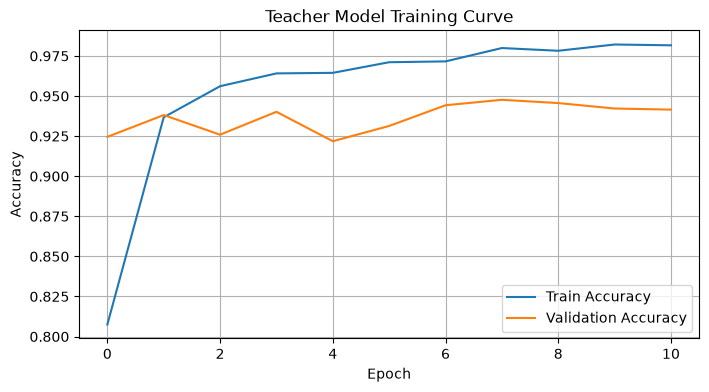

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


Teacher Test Accuracy: 0.9220

                    precision    recall  f1-score   support

           WALKING     0.9453    0.9415    0.9434       496
  WALKING_UPSTAIRS     0.9505    0.8960    0.9224       471
WALKING_DOWNSTAIRS     0.8911    0.9548    0.9218       420
           SITTING     0.9752    0.8004    0.8792       491
          STANDING     0.8106    0.9812    0.8878       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9220      2947
         macro avg     0.9288    0.9212    0.9218      2947
      weighted avg     0.9290    0.9220    0.9222      2947



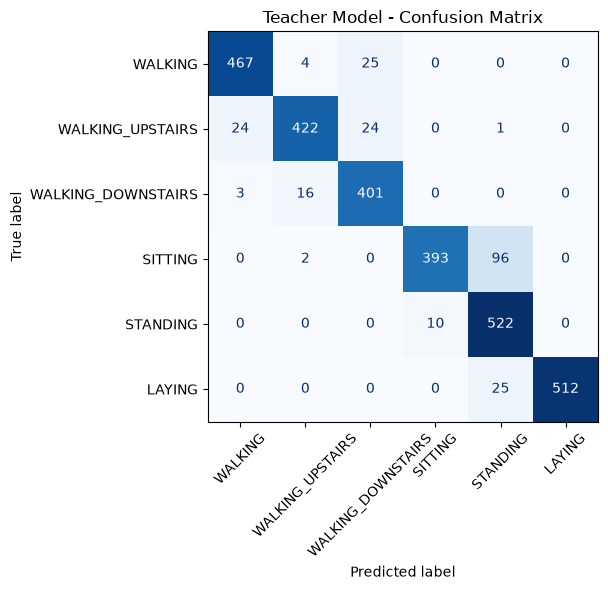

In [8]:
teacher_probs = teacher_model.predict(
    X_test,
    verbose=0
)

teacher_preds = np.argmax(
    teacher_probs,
    axis=1
)

teacher_acc = accuracy_score(
    y_test,
    teacher_preds
)

print(
    f"Teacher Test Accuracy: "
    f"{teacher_acc:.4f}\n"
)

print(classification_report(
    y_test,
    teacher_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
))

teacher_cm = confusion_matrix(
    y_test,
    teacher_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=teacher_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title("Teacher Model - Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 6ms/step - loss: 0.6947 - accuracy: 0.7674 - val_loss: 0.3262 - val_accuracy: 0.8906
Epoch 2/20
92/92 [==============================] - 0s 4ms/step - loss: 0.2689 - accuracy: 0.9078 - val_loss: 0.2485 - val_accuracy: 0.9137
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1705 - accuracy: 0.9441 - val_loss: 0.2348 - val_accuracy: 0.9157
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1358 - accuracy: 0.9534 - val_loss: 0.1561 - val_accuracy: 0.9320
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1074 - accuracy: 0.9621 - val_loss: 0.1495 - val_accuracy: 0.9279
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0854 - accuracy: 0.9725 - val_loss: 0.2112 - val_accuracy: 0.9293
Epoch 7/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0778 - accuracy: 0.9747 - val_loss: 0.1267 - val_accuracy: 0.9436
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


Baseline Student Test Accuracy: 0.9250

                    precision    recall  f1-score   support

           WALKING     0.9040    0.9677    0.9348       496
  WALKING_UPSTAIRS     0.9061    0.9214    0.9137       471
WALKING_DOWNSTAIRS     0.9526    0.8619    0.9050       420
           SITTING     0.9168    0.8982    0.9074       491
          STANDING     0.8801    0.9248    0.9019       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9250      2947
         macro avg     0.9266    0.9228    0.9240      2947
      weighted avg     0.9266    0.9250    0.9251      2947



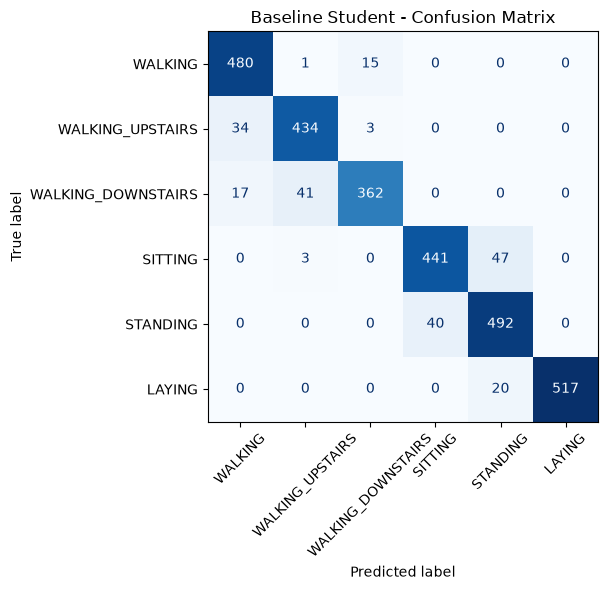

In [10]:
student_baseline_probs = (
    student_baseline_model.predict(
        X_test,
        verbose=0
    )
)

student_baseline_preds = np.argmax(
    student_baseline_probs,
    axis=1
)

student_baseline_acc = accuracy_score(
    y_test,
    student_baseline_preds
)

print(
    f"Baseline Student Test Accuracy: "
    f"{student_baseline_acc:.4f}\n"
)

print(classification_report(
    y_test,
    student_baseline_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
))

student_baseline_cm = confusion_matrix(
    y_test,
    student_baseline_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=student_baseline_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Baseline Student - Confusion Matrix"
)

plt.tight_layout()
plt.show()

# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [12]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()

        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(
            optimizer=optimizer,
            metrics=metrics
        )

        self.student_loss_fn = student_loss_fn

        self.distillation_loss_fn = (
            distillation_loss_fn
        )

        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        teacher_predictions = self.teacher(
            x,
            training=False
        )

        with tf.GradientTape() as tape:
            student_predictions = self.student(
                x,
                training=True
            )

            student_loss = self.student_loss_fn(
                y,
                student_predictions
            )

            # The models output probabilities rather
            # than raw logits. Taking the logarithm
            # recovers values proportional to logits.
            teacher_logits = tf.math.log(
                tf.clip_by_value(
                    teacher_predictions,
                    1e-7,
                    1.0
                )
            )

            student_logits = tf.math.log(
                tf.clip_by_value(
                    student_predictions,
                    1e-7,
                    1.0
                )
            )

            teacher_soft_targets = tf.nn.softmax(
                teacher_logits / self.temperature,
                axis=1
            )

            student_soft_targets = tf.nn.softmax(
                student_logits / self.temperature,
                axis=1
            )

            distillation_loss = (
                self.distillation_loss_fn(
                    teacher_soft_targets,
                    student_soft_targets
                )
                * self.temperature**2
            )

            loss = (
                self.alpha * student_loss
                + (1.0 - self.alpha)
                * distillation_loss
            )

        trainable_variables = (
            self.student.trainable_variables
        )

        gradients = tape.gradient(
            loss,
            trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                trainable_variables
            )
        )

        self.compiled_metrics.update_state(
            y,
            student_predictions
        )

        results = {
            metric.name: metric.result()
            for metric in self.metrics
        }

        results.update({
            "student_loss": student_loss,
            "distillation_loss": (
                distillation_loss
            ),
        })

        return results

    def test_step(self, data):
        x, y = data

        student_predictions = self.student(
            x,
            training=False
        )

        student_loss = self.student_loss_fn(
            y,
            student_predictions
        )

        self.compiled_metrics.update_state(
            y,
            student_predictions
        )

        results = {
            metric.name: metric.result()
            for metric in self.metrics
        }

        results.update({
            "student_loss": student_loss
        })

        return results

## 11. Train the Distilled Student


In [13]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.6514 - student_loss: 0.8605 - distillation_loss: 7.2531 - val_accuracy: 0.8661 - val_student_loss: 0.1442
Epoch 2/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.8570 - student_loss: 0.3553 - distillation_loss: 1.7706 - val_accuracy: 0.9477 - val_student_loss: 8.5898e-04
Epoch 3/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9066 - student_loss: 0.2335 - distillation_loss: 0.7918 - val_accuracy: 0.9307 - val_student_loss: 2.5914e-04
Epoch 4/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9294 - student_loss: 0.1738 - distillation_loss: 0.4831 - val_accuracy: 0.9436 - val_student_loss: 2.5728e-04
Epoch 5/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9447 - student_loss: 0.1354 - distillation_loss: 0.3098 - val_accuracy: 0.9436 - val_student_loss: 1.8745e-04


### Distillation Training Curves


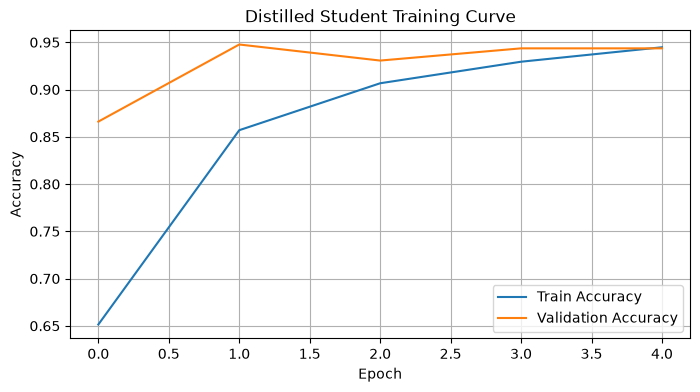

In [14]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.8839

                    precision    recall  f1-score   support

           WALKING     0.9473    0.9415    0.9444       496
  WALKING_UPSTAIRS     0.9545    0.8917    0.9221       471
WALKING_DOWNSTAIRS     0.8590    0.9286    0.8924       420
           SITTING     0.8988    0.5967    0.7173       491
          STANDING     0.7233    0.9530    0.8224       532
            LAYING     0.9906    0.9832    0.9869       537

          accuracy                         0.8839      2947
         macro avg     0.8956    0.8825    0.8809      2947
      weighted avg     0.8952    0.8839    0.8813      2947



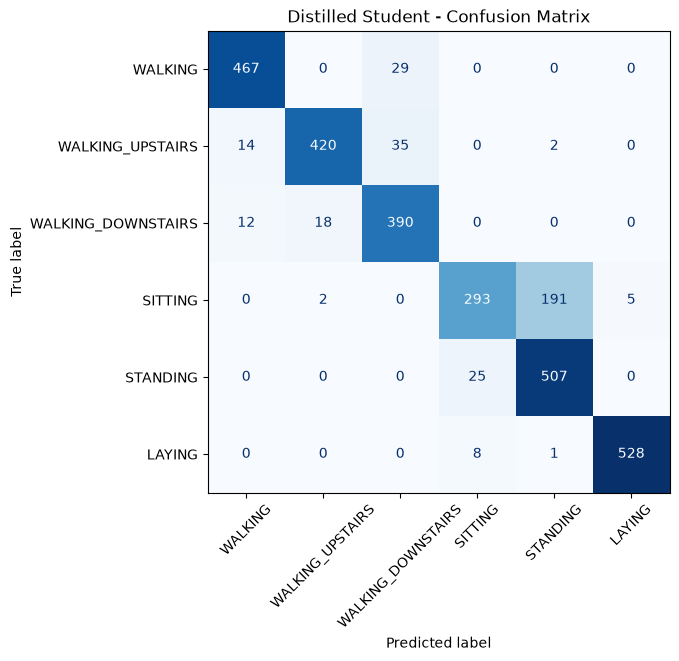

In [15]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [16]:
part1_results = pd.DataFrame(
    [
        [
            "Teacher",
            teacher_acc,
            teacher_model.count_params()
        ],
        [
            "Baseline Student",
            student_baseline_acc,
            student_baseline_model.count_params()
        ],
        [
            "Distilled Student",
            distilled_acc,
            distilled_student.count_params()
        ],
    ],
    columns=[
        "Model",
        "Test Accuracy",
        "Parameter Count"
    ]
)

part1_results.round({
    "Test Accuracy": 4
})

,Model,Test Accuracy,Parameter Count
0,Teacher,0.9220,185414
1,Baseline Student,0.9250,38246
2,Distilled Student,0.8839,38246


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [17]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [18]:
distilled_fp32_tflite = (
    convert_to_tflite_fp32(
        distilled_student
    )
)

distilled_fp32_size_kb = (
    save_binary_model(
        distilled_fp32_tflite,
        "distilled_student_fp32.tflite"
    )
)

(
    distilled_fp32_acc,
    distilled_fp32_preds
) = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

print(
    f"Distilled Student TFLite "
    f"FP32 Accuracy: "
    f"{distilled_fp32_acc:.4f}"
)

print(
    f"Distilled Student TFLite "
    f"FP32 Size (KB): "
    f"{distilled_fp32_size_kb:.2f}"
)

INFO:tensorflow:Assets written to: /tmp/tmpgguk4z21/assets


INFO:tensorflow:Assets written to: /tmp/tmpgguk4z21/assets


Distilled Student TFLite FP32 Accuracy: 0.8839
Distilled Student TFLite FP32 Size (KB): 151.51


2026-07-14 19:40:04.181977: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 19:40:04.182049: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 19:40:04.183823: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgguk4z21
2026-07-14 19:40:04.184536: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 19:40:04.184555: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgguk4z21
2026-07-14 19:40:04.187418: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-14 19:40:04.187914: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 19:40:04.211268: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpgguk4z21
2026-07

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [19]:
pruning_epochs = 10
batch_size = 64

steps_per_epoch = math.ceil(
    (0.8 * len(X_train)) / batch_size
)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=(
            steps_per_epoch
            * pruning_epochs
        ),
    )
}

student_for_pruning = (
    keras.models.clone_model(
        distilled_student
    )
)

student_for_pruning.set_weights(
    distilled_student.get_weights()
)

pruned_distilled_model = (
    prune_low_magnitude(
        student_for_pruning,
        **pruning_params
    )
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = (
    pruned_distilled_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=pruning_epochs,
        batch_size=batch_size,
        callbacks=pruning_callbacks,
        verbose=1
    )
)

Epoch 1/10
92/92 [==============================] - 2s 6ms/step - loss: 0.2114 - accuracy: 0.9126 - val_loss: 0.1795 - val_accuracy: 0.9225
Epoch 2/10
92/92 [==============================] - 0s 5ms/step - loss: 0.2089 - accuracy: 0.9138 - val_loss: 0.1839 - val_accuracy: 0.9286
Epoch 3/10
92/92 [==============================] - 0s 5ms/step - loss: 0.2193 - accuracy: 0.9117 - val_loss: 0.1782 - val_accuracy: 0.9395
Epoch 4/10
92/92 [==============================] - 0s 5ms/step - loss: 0.3544 - accuracy: 0.8544 - val_loss: 0.2433 - val_accuracy: 0.9470
Epoch 5/10
92/92 [==============================] - 1s 6ms/step - loss: 0.5606 - accuracy: 0.7861 - val_loss: 0.4208 - val_accuracy: 0.8464
Epoch 6/10
92/92 [==============================] - 1s 5ms/step - loss: 0.9616 - accuracy: 0.6094 - val_loss: 0.8015 - val_accuracy: 0.5391
Epoch 7/10
92/92 [==============================] - 0s 5ms/step - loss: 0.9675 - accuracy: 0.7179 - val_loss: 1.1965 - val_accuracy: 0.7349


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [21]:
pruned_with_mask_tflite = (
    convert_to_tflite_fp32(
        pruned_distilled_model
    )
)

pruned_with_mask_size_kb = (
    save_binary_model(
        pruned_with_mask_tflite,
        "pruned_distilled_with_mask_fp32.tflite"
    )
)

(
    pruned_with_mask_acc,
    pruned_with_mask_preds
) = evaluate_tflite_model(
    pruned_with_mask_tflite,
    X_test,
    y_test
)

stripped_pruned_model = strip_pruning(
    pruned_distilled_model
)

converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(
        stripped_pruned_model
    )
)

converter.optimizations = [
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]

stripped_sparse_tflite = (
    converter.convert()
)

stripped_sparse_size_kb = (
    save_binary_model(
        stripped_sparse_tflite,
        "distilled_stripped_sparse_fp32.tflite"
    )
)

(
    stripped_sparse_acc,
    stripped_sparse_preds
) = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)

print(
    f"Pruned distilled model with "
    f"mask accuracy: "
    f"{pruned_with_mask_acc:.4f}"
)

print(
    f"Pruned distilled model with "
    f"mask size (KB): "
    f"{pruned_with_mask_size_kb:.2f}"
)

print(
    f"Stripped sparse distilled "
    f"model accuracy: "
    f"{stripped_sparse_acc:.4f}"
)

print(
    f"Stripped sparse distilled "
    f"model size (KB): "
    f"{stripped_sparse_size_kb:.2f}"
)

INFO:tensorflow:Assets written to: /tmp/tmpdj5vm5n8/assets


INFO:tensorflow:Assets written to: /tmp/tmpdj5vm5n8/assets
2026-07-14 19:40:58.513473: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 19:40:58.513514: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 19:40:58.513791: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdj5vm5n8
2026-07-14 19:40:58.515439: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 19:40:58.515449: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpdj5vm5n8
2026-07-14 19:40:58.520549: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 19:40:58.555118: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpdj5vm5n8
2026-07-14 19:40:58.566071: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp8481l1hl/assets


INFO:tensorflow:Assets written to: /tmp/tmp8481l1hl/assets


Pruned distilled model with mask accuracy: 0.8884
Pruned distilled model with mask size (KB): 304.30
Stripped sparse distilled model accuracy: 0.8884
Stripped sparse distilled model size (KB): 80.95


2026-07-14 19:40:59.013746: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 19:40:59.013788: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 19:40:59.013920: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8481l1hl
2026-07-14 19:40:59.014342: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 19:40:59.014352: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8481l1hl
2026-07-14 19:40:59.015476: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 19:40:59.026834: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8481l1hl
2026-07-14 19:40:59.031829: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 17906 m

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [22]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpoi0x6mm1/assets


INFO:tensorflow:Assets written to: /tmp/tmpoi0x6mm1/assets
/home/rambo/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 19:41:07.594386: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 19:41:07.594433: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 19:41:07.594606: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpoi0x6mm1
2026-07-14 19:41:07.595226: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 19:41:07.595241: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpoi0x6mm1
2026-07-14 19:41:07.596365: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

Stripped Sparse + INT8 Accuracy: 0.8873
Stripped Sparse + INT8 Size (KB): 42.45


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [23]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.883950,151.507812
1,Pruned Distilled TFLite (with mask),FP32,0.888361,304.296875
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.888361,80.953125
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.887343,42.453125


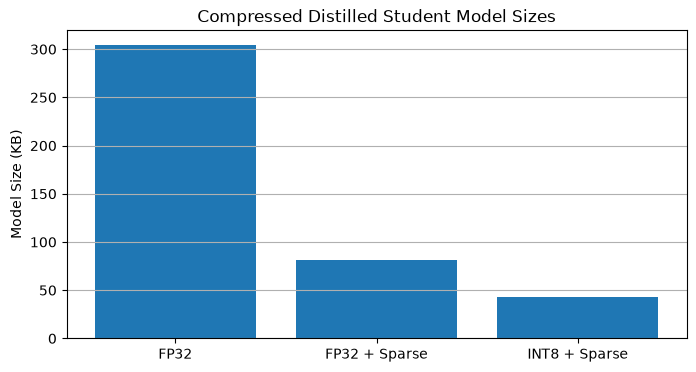

In [24]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


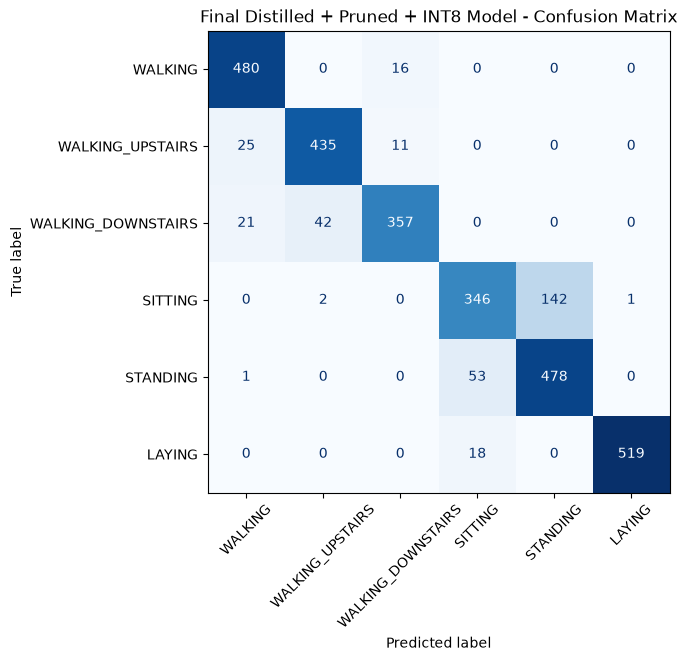

In [25]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**? The baseline student performed better than the distilled student in this run. The baseline student achieved 92.50% accuracy, while the distilled student achieved 88.39% accuracy, a difference of approximately 4.11 percentage points.
2. Did **knowledge distillation** help the smaller model retain performance? No. In this experiment, knowledge distillation did not improve the smaller student model. The distilled student had the same number of parameters as the baseline student, but its test accuracy was lower.
3. What happened to the model size after **pruning** and after **INT8 quantization**? The original distilled FP32 TensorFlow Lite model was approximately 151.51 KB. The model with pruning wrappers increased to 304.30 KB because the pruning masks and metadata added overhead. After stripping the pruning wrappers and enabling sparse storage, the size decreased to 80.95 KB. Applying INT8 quantization reduced it further to 42.45 KB, approximately a 72% reduction compared with the original distilled FP32 model.
4. Which model would you choose for **Arduino deployment**, and why? I would choose the stripped sparse INT8 model. It achieved 88.73% accuracy while requiring only 42.45 KB of storage. This provides the best balance between model size and classification accuracy for deployment on the Arduino device.
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate? The final model is a good TinyML candidate because it combines a small student architecture, sparse weights, and 8-bit integer quantization. These techniques greatly reduce its storage and computational requirements while preserving most of its classification performance.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
